C:\Windows\Temp\ipykernel_10644\3346071991.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, y='reason', order=order_reasons, palette='Reds_r')


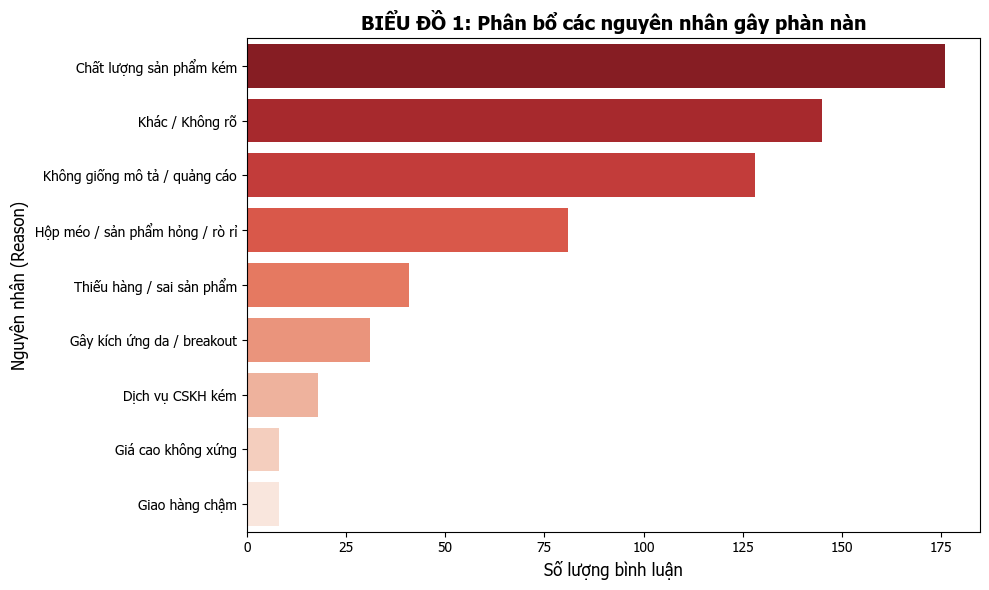

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Arial', 'DejaVu Sans']

# Đọc file dữ liệu
df = pd.read_csv("D:/DataReviews/shopee_reviews_keyword_labeled3.csv")

df_plot = df.copy()

# BIỂU ĐỒ 1: TỔNG QUAN CÁC NGUYÊN NHÂN LỖI (BAR CHART)
plt.figure(figsize=(10, 6))

# Đếm số lượng từng nguyên nhân để sắp xếp (từ cao xuống thấp)
order_reasons = df_plot['reason'].value_counts().index

# Vẽ biểu đồ
sns.countplot(data=df_plot, y='reason', order=order_reasons, palette='Reds_r')

plt.title('BIỂU ĐỒ 1: Phân bổ các nguyên nhân gây phàn nàn', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng bình luận', fontsize=12)
plt.ylabel('Nguyên nhân (Reason)', fontsize=12)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('D:/DataReviews/bieu_do_1_tong_quan_loi.png')
plt.show()

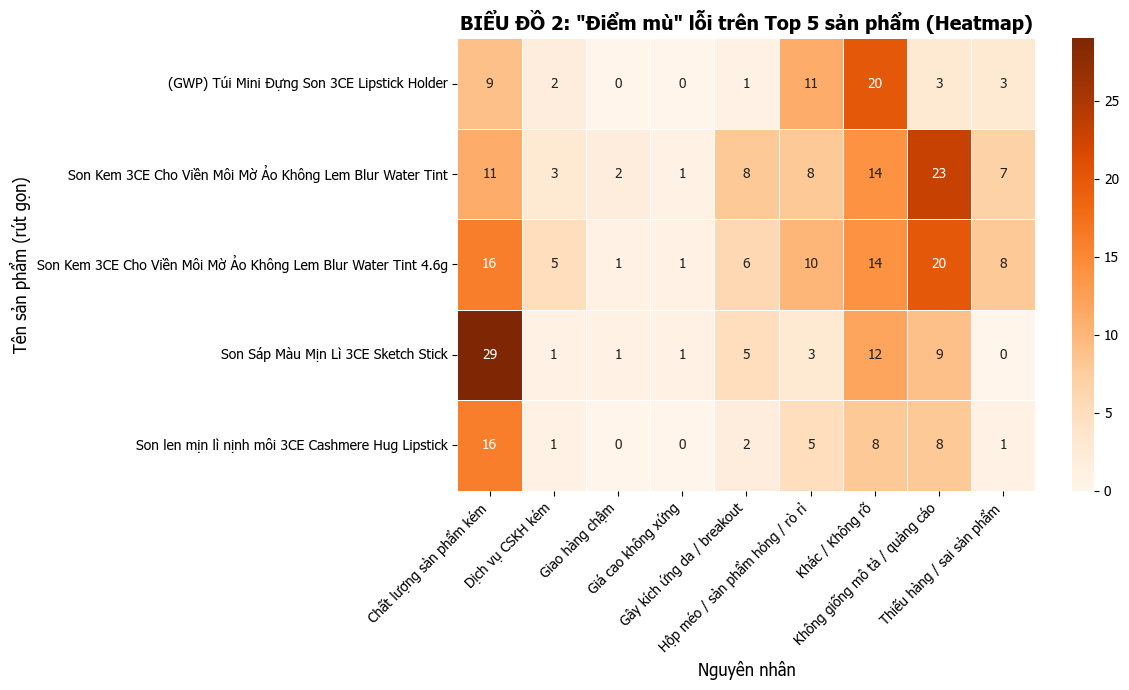

In [ ]:
# BIỂU ĐỒ 2: HEATMAP MỐI QUAN HỆ GIỮA SẢN PHẨM VÀ LỖI
# Lấy Top 5 sản phẩm bị phàn nàn nhiều nhất 
top_5_products = df_plot['product'].value_counts().head(5).index
df_top_products = df_plot[df_plot['product'].isin(top_5_products)]

# Tạo bảng chéo (crosstab) giữa Sản phẩm và Nguyên nhân
pivot_table = pd.crosstab(df_top_products['product'], df_top_products['reason'])

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='Oranges', linewidths=.5)

plt.title('BIỂU ĐỒ 2: "Điểm mù" lỗi trên Top 5 sản phẩm (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Nguyên nhân', fontsize=12)
plt.ylabel('Tên sản phẩm (rút gọn)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('D:/DataReviews/bieu_do_2_heatmap_san_pham.png')
plt.show()

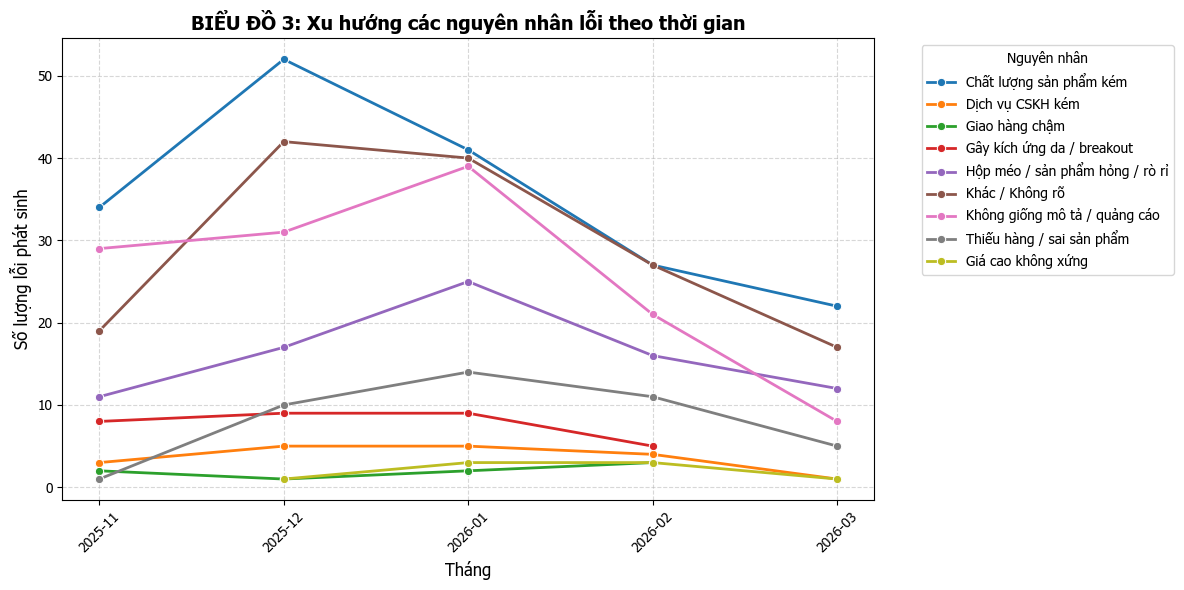

In [ ]:
# BIỂU ĐỒ 3: XU HƯỚNG LỖI THEO THỜI GIAN (LINE CHART)
# Chuyển đổi cột created_at sang định dạng datetime
df_plot['created_at'] = pd.to_datetime(df_plot['created_at'], errors='coerce')

# Tạo cột 'Tháng-Năm' (Ví dụ: 2025-11)
df_plot['year_month'] = df_plot['created_at'].dt.to_period('M').astype(str)

# Nhóm dữ liệu theo tháng và nguyên nhân
trend_data = df_plot.groupby(['year_month', 'reason']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='year_month', y='count', hue='reason', marker='o', linewidth=2)

plt.title('BIỂU ĐỒ 3: Xu hướng các nguyên nhân lỗi theo thời gian', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số lượng lỗi phát sinh', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nguyên nhân', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('bieu_do_3_xu_huong_thoi_gian.png')
plt.show()